## Яндекс кружок, Искусственный Интеллект. Домашнее задание на сверточный классификатор.
Домашнее задание взято из курса "Глубинное обучение 1 / Введение в глубинное обучение, ФКН ВШЭ"

### Оценивание

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### О задании

В этом задании вам предстоит познакомиться со сверточными сетями и их обучением для классификации изображений с использованием библиотеки PyTorch.

С садание, конечно, справятся современные LLM, но тогда Вы не получите ценных базовых знаний. - **Рекомендую выполнять задание самостоятельно!**


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split

## 0. Загрузка данных

Работать мы будем с набором данных [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html). CIFAR10 представляет собой набор изображений 32х32 пикселя, разделенных на 10 классов.

![title](https://pytorch.org/tutorials/_images/cifar10.png)




Набор данных уже определен в <code>torchvision.datasets</code>, так что возьмем его оттуда. 



In [2]:
def get_cifar10_data(batch_size, transform_train):
    torch.manual_seed(0)
    np.random.seed(0)

    transform_test = transforms.Compose(
        [transforms.ToTensor(),
         # Переводим цвета пикселей в отрезок [-1, 1]
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    )
    
    # Загружаем данные
    trainvalset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                               download=True, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform_test)
    
    # В датасете определено разбиение только на train и test,
    # так что валидацию дополнительно выделяем из обучающей выборки
    train_idx, valid_idx = train_test_split(np.arange(len(trainvalset)), test_size=0.3, 
                                            shuffle=True, random_state=0)
    trainset = torch.utils.data.Subset(trainvalset, train_idx)
    valset = torch.utils.data.Subset(trainvalset, valid_idx)

    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                               shuffle=True, num_workers=2)
    val_loader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                             shuffle=False, num_workers=2)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                              shuffle=False, num_workers=2)
    
    return train_loader, val_loader, test_loader
    

In [3]:
transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, 
                                                         transform_train=transform)

Посмотрим на изображения:

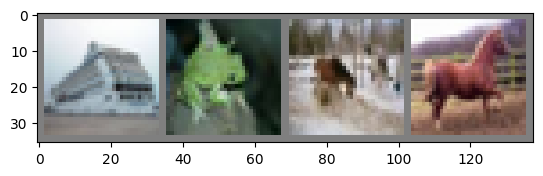

ship frog horse horse


In [4]:
def imshow(img):
    img = img / 2 + 0.5    
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(*[classes[labels[i]] for i in range(4)])

## 1. Задание сверточной сети (3 балла)

Теперь нам нужно задать сверточную нейронную сеть, которую мы будем обучать классифицировать изображения.

Используем сеть, основанную на одном блоке архитектуры ResNet.

<img src="https://i.ibb.co/2hg962h/basic-block.png" width="500"/>

__Указания:__

- Все сверточные слои должны иметь 32 выходных канала, а также не должны изменять ширину и высоту изображения.
- Выход блока сократите до размерности 32х4х4, применив average pooling.
- Для получения итоговых логитов, распрямите выход пулинга в вектор из 512 элементов, а затем пропустите его через линейный слой.

**Задание 1.1 (3 балла).**

Определите архитектуру сети соответственно схеме и указаниям выше.

Ключевые слова: <code>Conv2d</code>, <code>BatchNorm2d</code>, <code>AvgPool2d</code>.

In [5]:
n_classes = 10

class BasicBlockNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(32)
        )
        self.skip = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=(1, 1), padding=0)
        self.relu = nn.ReLU()
        self.pool = nn.AvgPool2d(kernel_size=(8, 8))
        self.linear = nn.Linear(in_features=32*4*4, out_features=n_classes)
    def forward(self, x):
        x1 = self.block1(x)
        x2 = self.skip(x)
        out = x1 + x2
        out = self.relu(out)
        out = self.pool(out)
        out = torch.flatten(out, 1)
        out = self.linear(out)
        return out

In [6]:
net = BasicBlockNet()
net

BasicBlockNet(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (skip): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
  (relu): ReLU()
  (pool): AvgPool2d(kernel_size=(8, 8), stride=(8, 8), padding=0)
  (linear): Linear(in_features=512, out_features=10, bias=True)
)

Проверим, что выход сети имеет корректную размерность:

In [23]:
assert net(torch.zeros((10, 3, 32, 32))).shape == (10, 10)

Чтобы проводить вычисления на GPU, в PyTorch необходимо руками перекладывать объекты, с которыми вы хотите проводить вычисления, на графический ускоритель. Это делается следующим образрм:

In [7]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [8]:
net = net.to(device)

Подключение GPU в google.colab:

**Среда выполнения** -> **Сменить среду выполнения** -> **Аппаратный ускоритель** -> **GPU**

## 2. Обучение и тестирование модели (3 балла)

**Задание 2.1 (2 балла).** Переходим к обучению модели. Заполните пропуски в функциях <code>test</code> и <code>train_epoch</code>. В качестве функции потерь будем использовать [кросс-энтропию](https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html), а в качестве метрики качества accuracy.

In [9]:
def test(model, loader):
    loss_log = []
    acc_log = []
    model.eval()
    
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        logits = model(data)
        loss = nn.functional.cross_entropy(logits, target)
        loss_log.append(loss.item())
        predict = torch.argmax(logits, dim=1)
        acc = (predict == target).float().mean()
        acc_log.append(acc.item()) 
        
    return np.mean(loss_log), np.mean(acc_log)

def train_epoch(model, optimizer, train_loader):
    loss_log = []
    acc_log = []
    model.train()
    
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        logits = model(data)
        loss = nn.functional.cross_entropy(logits, target)
        loss_log.append(loss.item())
        loss.backward()
        optimizer.step()  
        predict = torch.argmax(logits, dim=1)
        acc = (predict == target).float().mean()
        acc_log.append(acc.item()) 

    return loss_log, acc_log

def train(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader)
        val_loss, val_acc = test(model, val_loader)
        
        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)
        
        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        print(f"Epoch {epoch}")
        print(f" train loss: {np.mean(train_loss)}, train acc: {np.mean(train_acc)}")
        print(f" val loss: {val_loss}, val acc: {val_acc}\n")
        
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()
                

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log

Запустим обучение модели. В качестве оптимизатора будем использовать стохастический градиентный спуск, который является де-факто стандартом в задачах компьютерного зрения (наравне с <code>Adam</code>).

__Замечание:__ Для достижения наилучшего качества в нашем случае потребуется обучать модель несколько сотен эпох. Однако в целях экономии вашего времени и сил, во всех экспериментах мы ограничимся 20 эпохами.

In [32]:
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader)

Epoch 0
 train loss: 0.7536473498156999, train acc: 0.7374151215038962
 val loss: 0.851535373672526, val acc: 0.7123670212765958

Epoch 1
 train loss: 0.7502033017453154, train acc: 0.7359746344782535
 val loss: 0.8661830057489112, val acc: 0.7042109930768926

Epoch 2
 train loss: 0.7432636386515672, train acc: 0.7415488705556615
 val loss: 0.8494371226493348, val acc: 0.713408688027808

Epoch 3
 train loss: 0.742728574511338, train acc: 0.7401777553819869
 val loss: 0.8452106309697983, val acc: 0.7118351063829788

Epoch 4
 train loss: 0.7302300571523593, train acc: 0.7448746409451068
 val loss: 0.9015117687113742, val acc: 0.6944813829787234

Epoch 5
 train loss: 0.7319944478585035, train acc: 0.7456214090152022
 val loss: 0.8927468074128982, val acc: 0.6936170212765957

Epoch 6
 train loss: 0.7188119559227004, train acc: 0.749461347703742
 val loss: 0.9205151431103971, val acc: 0.6858377659574468

Epoch 7
 train loss: 0.7131171916259055, train acc: 0.7519424132716721
 val loss: 0.875

Посчитайте точность на тестовой выборке:

In [ ]:
val_loss, val_acc = test(net, test_loader)
print(f"Точность: {val_acc * 100}%\n")

Точность: 69.99402866242038%



Если вы все сделали правильно, у вас должна была получиться точность $\ge 67\%$.

**Задание 2.2 (1 балл).** Постройте графики зависимости функции потерь и точности классификации от номера шага оптимизатора. На каждом графике расположите данные и для обучающей и для валидационной выборки, итого у вас должно получиться два графика. Обратите внимание, что на обучающей выборке эти данные считаются по каждому батчу, на валидационной же они считаются по всей выборке раз в эпоху.

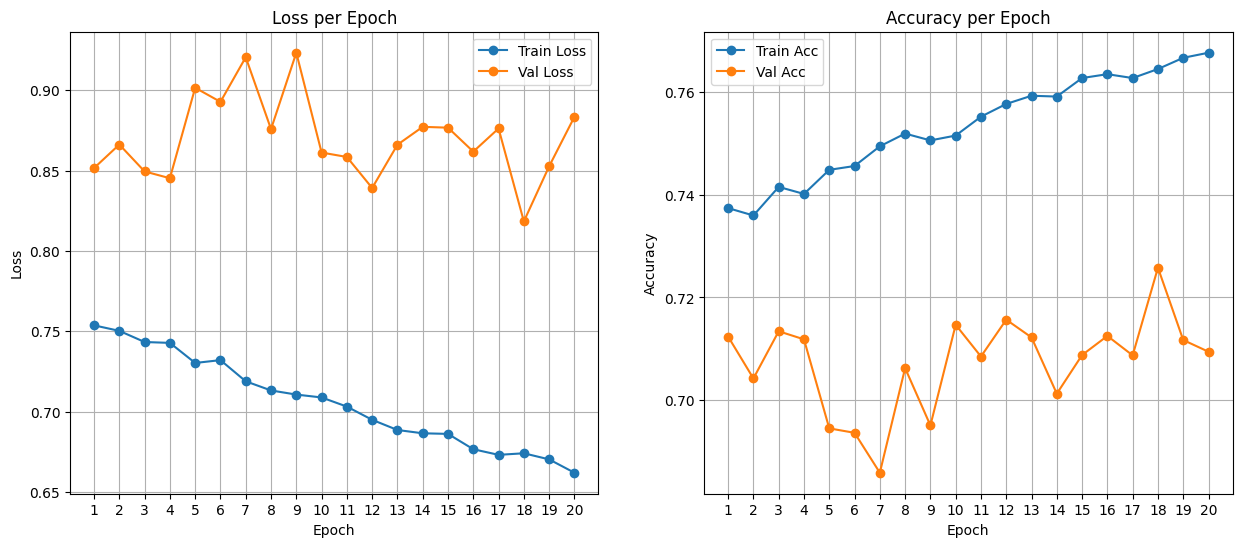

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n_epochs = 20
bpe = len(train_loss_log) // n_epochs

train_loss_bpe = []
train_acc_bpe = []

for i in range(0, len(train_loss_log), bpe):
    train_loss_bpe.append(np.mean(train_loss_log[i : i + bpe]))
    train_acc_bpe.append(np.mean(train_acc_log[i: i + bpe]))

epochs = np.arange(1, n_epochs + 1)
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_bpe, label='Train Loss', marker='o')
plt.plot(epochs, val_loss_log, label='Val Loss', marker='o')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc_bpe, label='Train Acc', marker='o')
plt.plot(epochs, val_acc_log, label='Val Acc', marker='o')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.show()

Из графика видно что модель переобучается, тк трейн стабильно падает на лоссе и растёт на вале, а валидация скачит и там и там.

Это происходит потому, что модель слишком слишком сложная и начинает запоминать конкретные примеры из трейна.

## 3. Расписание длины шага (2 балла)

С курса "Машинное обучение 1" вы уже должны знать, что сходимость стохастического градиентного спуска мы можем теоретически гарантировать только если будем определенным образом со временем уменьшать длину шага. На практике при обучении нейронных сетей такая техника оказывается очень полезной, однако теоретически обоснованными способами уменьшения длины шага фантазия не ограничивается.

Одним из простейших способов является кусочно постоянная функция: на нескольких фиксированных эпохах уменьшаем длину шага в константу раз.

In [43]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

Epoch 0
 train loss: 1.510115820376485, train acc: 0.45964187786827576
 val loss: 1.2694829788613826, val acc: 0.5486923759287976

Epoch 1
 train loss: 1.1866883503671537, train acc: 0.5841317903625028
 val loss: 1.1227217874628432, val acc: 0.6088652483960415

Epoch 2
 train loss: 1.0566041301765652, train acc: 0.6322840493601463
 val loss: 1.0326830118260486, val acc: 0.6427748228641267

Epoch 3
 train loss: 1.0047508462909371, train acc: 0.6506431183387854
 val loss: 1.0122923171266596, val acc: 0.6477615249917862

Epoch 4
 train loss: 0.9654194875543689, train acc: 0.6629709128487916
 val loss: 0.9857481880390898, val acc: 0.6601507093044038

Epoch 5
 train loss: 0.9436914450071847, train acc: 0.6731522591066099
 val loss: 1.0049540451232424, val acc: 0.6546764186088075

Epoch 6
 train loss: 0.9194014900563185, train acc: 0.6796038456983061
 val loss: 1.003928195669296, val acc: 0.6567375888215735

Epoch 7
 train loss: 0.8941816810716005, train acc: 0.6906339775709609
 val loss: 1.

Посчитайте точность на тестовой выборке:

In [44]:
val_loss, val_acc = test(net, test_loader)
print(f"Точность: {val_acc * 100}%\n")

Точность: 71.11863057324841%



**Задание 3.0 (0.5 баллов).** Здесь может возникнуть вопрос: а что будет, если мы не будем уменьшать длину шага в процессе обучения, а сразу возьмем констатную, равную значению нашей кусочно-постоянной функции на последних эпохах, то есть $0.001$ в нашем случае. Запустите обучение и проверьте, что в таком случае мы получим худшее качество на тестовой выборке.

In [45]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader)
val_loss, val_acc = test(net, test_loader)
print(f"Точность: {val_acc * 100}%\n")

Epoch 0
 train loss: 1.8196251621194035, train acc: 0.3599136524052245
 val loss: 1.6072129041590588, val acc: 0.436923758907521

Epoch 1
 train loss: 1.531205989978867, train acc: 0.4642938756855576
 val loss: 1.4470407577271158, val acc: 0.48885195039688273

Epoch 2
 train loss: 1.4123147774004194, train acc: 0.5046846435100548
 val loss: 1.366043513886472, val acc: 0.5158909574468085

Epoch 3
 train loss: 1.3488812130591552, train acc: 0.5260307848780421
 val loss: 1.3116275574298615, val acc: 0.5357491135597229

Epoch 4
 train loss: 1.299898905771524, train acc: 0.5435655524569412
 val loss: 1.2787220701258233, val acc: 0.5512411348363186

Epoch 5
 train loss: 1.2619502506264821, train acc: 0.5570563463667847
 val loss: 1.2304294639445366, val acc: 0.5684840425531915

Epoch 6
 train loss: 1.2269511915865938, train acc: 0.5692494777482432
 val loss: 1.2070692673642585, val acc: 0.577593085106383

Epoch 7
 train loss: 1.1962904257791787, train acc: 0.5803204165734146
 val loss: 1.224

Как мы видим, полученна самая низкая точность.

**Задание 3.1 (1.5 балла).** Изучите, какие еще способы уменьшения длины шага представлены в <code>torch.optim.lr_scheduler</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними. Удалось ли добиться улучшения качества на тестовой выборке?

In [10]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

Epoch 0
 train loss: 1.494674475798877, train acc: 0.46730951297435724
 val loss: 1.2774453386347344, val acc: 0.5508200355032657

Epoch 1
 train loss: 1.1721005699098437, train acc: 0.5900651279707495
 val loss: 1.1258743128878006, val acc: 0.6157136526513607

Epoch 2
 train loss: 1.0566443245197346, train acc: 0.6354302690931386
 val loss: 1.0223759539583896, val acc: 0.6469858156873824

Epoch 3
 train loss: 1.0058993474874898, train acc: 0.6525896121858461
 val loss: 0.9933009309971587, val acc: 0.6584441489361702

Epoch 4
 train loss: 0.9657469619562683, train acc: 0.6639870070670161
 val loss: 0.9639650778567538, val acc: 0.6648936170212766

Epoch 5
 train loss: 0.9315881937251884, train acc: 0.6782980216922446
 val loss: 0.9620173185429675, val acc: 0.6677969859001485

Epoch 6
 train loss: 0.9021159032363124, train acc: 0.6853045835355518
 val loss: 0.9299282609148228, val acc: 0.6783687944107867

Epoch 7
 train loss: 0.8755379776850043, train acc: 0.6950411334552102
 val loss: 0

In [11]:
val_loss, val_acc = test(net, test_loader)
print(f"Точность: {val_acc * 100}%\n")

Точность: 72.02428343949045%



In [13]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

Epoch 0
 train loss: 1.5159275330180877, train acc: 0.4590787412479547
 val loss: 1.3331644476728237, val acc: 0.5277260638297873

Epoch 1
 train loss: 1.224354453888846, train acc: 0.5666051841523138
 val loss: 1.1580730767960243, val acc: 0.5956338654173181

Epoch 2
 train loss: 1.096579489259005, train acc: 0.6153736288848263
 val loss: 1.0979802687117395, val acc: 0.6198803191489362

Epoch 3
 train loss: 1.023641235976594, train acc: 0.6438569144313471
 val loss: 0.9997772493260972, val acc: 0.6497340425531914

Epoch 4
 train loss: 0.9753164523698294, train acc: 0.66129374514986
 val loss: 1.0451994056397296, val acc: 0.6360150710065314

Epoch 5
 train loss: 0.9461133147724368, train acc: 0.6701937517256797
 val loss: 0.9913823292610493, val acc: 0.6622783688788718

Epoch 6
 train loss: 0.9240980373875969, train acc: 0.6778981130999229
 val loss: 0.9878858728611722, val acc: 0.6584441489361702

Epoch 7
 train loss: 0.9025932350476873, train acc: 0.6860391094436157
 val loss: 0.9816

In [14]:
val_loss, val_acc = test(net, test_loader)
print(f"Точность: {val_acc * 100}%\n")

Точность: 69.79498407643312%



Описание LR Schedulers:
   * CosineAnnealingLR: Плавно изменяет скорость обучения по косинусоидальной кривой. Позволяет модели сначала быстро исследовать пространство решений, затем точно настраиваться.
   * ReduceLROnPlateau: Динамически снижает скорость обучения, если метрика на валидации (например, val_loss) перестает улучшаться в течение заданного числа эпох. Помогает выйти из "плато" обучения.

CosineAnnealingLR показал лучший результат (72%), поскольку его планомерное снижение скорости обучения оказалось эффективнее для данной задачи. ReduceLROnPlateau (69.7%) и MultiStepLR (71.1%), в итоге базовая модель была улучшена, но не сильно. Постоянный низкий LR (66.5%) оказался неэффективным.

## 4. Аугментации данных (2 балла)

Еще одной стандартной техникой, применяющейся в глубинном обучении, а особенно часто в компьютерном зрении, являются аугментации данных. Суть аугментаций состоит в том, что мы можем некоторым синтетическим образом видоизменять объекты обучающей выборки, тем самым расширяя ее, а также делая итоговую модель более устойчивой к таким изменениям.

Простейшая аугментация, которую можно применить к картинкам — разворот картинки по горизонтальной оси. То есть при обучении модели с вероятностью $0.5$ мы будем разворачивать картинку из обучающей выборки.

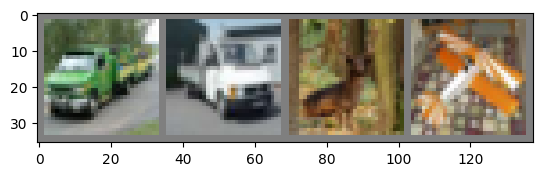

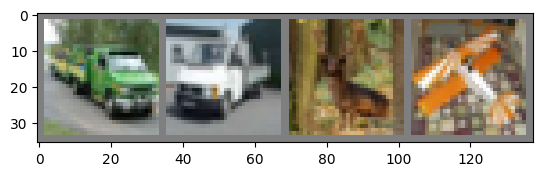

In [10]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))

imshow(torchvision.utils.make_grid(transforms.functional.hflip(images[:4])))

Наиболее удобным способом работы с аугментациями в PyTorch является их задание в списке <code>transforms</code>, который затем передается в загрузчик данных. Обучим нашу сеть, применяя горизонтальные повороты:

In [17]:
transform = transforms.Compose(
        [transforms.RandomHorizontalFlip(),
         transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

Epoch 0
 train loss: 1.4876639873497666, train acc: 0.4697660943271909
 val loss: 1.320160122120634, val acc: 0.5292996454746165

Epoch 1
 train loss: 1.1967257890012626, train acc: 0.5800918973778022
 val loss: 1.1180353035318091, val acc: 0.6118794327086591

Epoch 2
 train loss: 1.064912650005473, train acc: 0.6274973884143167
 val loss: 1.1190146836828678, val acc: 0.6181737590343395

Epoch 3
 train loss: 1.0015429456665486, train acc: 0.6522549948701039
 val loss: 0.9972381289969099, val acc: 0.6554299646235527

Epoch 4
 train loss: 0.9583340159717818, train acc: 0.667626991459395
 val loss: 0.9885730451725899, val acc: 0.6541445037151905

Epoch 5
 train loss: 0.9192938367671025, train acc: 0.6812524484977862
 val loss: 0.9482513711807575, val acc: 0.6652039007937655

Epoch 6
 train loss: 0.9018717147750436, train acc: 0.6897362236348977
 val loss: 0.9845733908896751, val acc: 0.6563829787234042

Epoch 7
 train loss: 0.8907397023284676, train acc: 0.692588632895698
 val loss: 0.897

Посчитайте точность на тестовой выборке:

In [18]:
val_loss, val_acc = test(net, test_loader)
print(f"Точность: {val_acc * 100}%\n")

Точность: 73.07921974522293%



**Задание 4.1 (2 балла).** Изучите, какие еще способы аугментаций изображений представлены в <code>torchvision.transforms</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними (по отдельности и вместе). Удалось ли добиться улучшения качества на тестовой выборке?

In [11]:
transform = transforms.Compose(
        [transforms.RandomHorizontalFlip(),
         transforms.RandomRotation(15),
         transforms.ColorJitter(brightness=0.2, contrast=0.2),
         transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(batch_size=64, transform_train=transform)

net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

Epoch 0
 train loss: 1.5890286347983742, train acc: 0.4296201685446926
 val loss: 1.4158961625809365, val acc: 0.49024822699262743

Epoch 1
 train loss: 1.3397897552746523, train acc: 0.5234232175502742
 val loss: 1.237901151687541, val acc: 0.5680851063829787

Epoch 2
 train loss: 1.2241863779437607, train acc: 0.5691719444185985
 val loss: 1.1542043891358882, val acc: 0.5982712765957446

Epoch 3
 train loss: 1.1533755646981094, train acc: 0.5976062614259597
 val loss: 1.1043955252525655, val acc: 0.6167331561129143

Epoch 4
 train loss: 1.108159156342529, train acc: 0.6129945808616373
 val loss: 1.139339733631053, val acc: 0.5967863476022761

Epoch 5
 train loss: 1.0802693544619697, train acc: 0.621841538322909
 val loss: 1.0918352040838688, val acc: 0.6169991135597229

Epoch 6
 train loss: 1.0587855191727662, train acc: 0.6310435166306644
 val loss: 1.0322873252503415, val acc: 0.6407136526513607

Epoch 7
 train loss: 1.042258010921792, train acc: 0.6365891878086208
 val loss: 1.017

In [12]:
val_loss, val_acc = test(net, test_loader)
print(f"Точность: {val_acc * 100}%\n")

Точность: 70.51154458598727%



Описание аугментаций:
   * RandomRotation: Случайным образом поворачивает изображения на заданный угол. Делает модель устойчивой к изменению ориентации объектов.
   * ColorJitter: Случайным образом меняет яркость и контрастность изображений. Помогает модели адаптироваться к разным условиям освещения.

Выводы по экспериментам: RandomHorizontalFlip дал наибольший прирост точности (73%). Комбинация RandomHorizontalFlip, RandomRotation и ColorJitter показала худший результат (70%). Это говорит о том, что чрезмерно агрессивные аугментации могут искажать изображения слишком сильно, затрудняя обучение модели. Для оптимального результата требуется точная настройка аугментаций, для конкретной задачи.

## Бонус. Логирование в wandb (2 балла)

На практике специалиста по глубинному обучению часто встречаются ситуации, когда нейросеть учится на каком-то удаленном сервере. И обычно вам хочется отслеживать прогресс обучения, особенно когда время обучения модели исчисляется днями или неделями. Для таких целей существует несколько инструментов. Вероятно, самый популярный из них — [wandb](https://wandb.ai/site).

Ваша задача состоит в том, чтобы разобраться как им пользоваться, и повторить задания 2.1 и 2.2 с его использованием. Обучение вы можете запускать в этом же ноутбуке, но теперь вам необходимо через wandb логировать значения функции потерь и точности на обучающей выборке и на валидационной. Результатом работы должны быть ваш код и публичная ссылка на страничку с графиками, идентичными графикам в задании 2.2.

In [9]:
!pip install wandb

In [10]:
import wandb
import torch.optim as optim

In [15]:
wandb.login()

True

In [12]:
def test(model, loader):
    loss_log = []
    acc_log = []
    model.eval()
    
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        logits = model(data)
        loss = nn.functional.cross_entropy(logits, target)
        loss_log.append(loss.item())
        predict = torch.argmax(logits, dim=1)
        acc = (predict == target).float().mean()
        acc_log.append(acc.item()) 
        
    return np.mean(loss_log), np.mean(acc_log)

def train(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []
    wandb.init(
        project="resnet-cifar10",
        entity="fulovt",
        config={
            "learning_rate": optimizer.param_groups[0]['lr'],
            "epochs": n_epochs,
            "architecture": "BasicBlockNet",
            "scheduler": type(scheduler).__name__ if scheduler else "None"
        }
    )
    model.train()
    for epoch in range(n_epochs):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            logits = model(data)
            loss = nn.functional.cross_entropy(logits, target)
            loss.backward()
            optimizer.step()
            predict = torch.argmax(logits, dim=1)
            acc = (predict == target).float().mean()
            wandb.log({
                "train_loss": loss.item(),
                "train_acc": acc.item(),
                "lr": optimizer.param_groups[0]['lr']
            })
        val_loss, val_acc = test(model, val_loader)
        wandb.log({
            "val_loss": val_loss,
            "val_acc": val_acc,
            "epoch": epoch
        })
        print(f"Epoch {epoch}")
        print(f" val loss: {val_loss}, val acc: {val_acc}\n")
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()
    wandb.finish()
    return train_loss_log, train_acc_log, val_loss_log, val_acc_log

In [ ]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

In [20]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(net, optimizer, 20, train_loader, val_loader, scheduler)

Epoch 0: val_acc: 0.4786
Epoch 1: val_acc: 0.5481
Epoch 2: val_acc: 0.5759
Epoch 3: val_acc: 0.5895
Epoch 4: val_acc: 0.6054
Epoch 5: val_acc: 0.6084
Epoch 6: val_acc: 0.6193
Epoch 7: val_acc: 0.6150
Epoch 8: val_acc: 0.6350
Epoch 9: val_acc: 0.6436
Epoch 10: val_acc: 0.6537
Epoch 11: val_acc: 0.6562
Epoch 12: val_acc: 0.6671
Epoch 13: val_acc: 0.6658
Epoch 14: val_acc: 0.6704
Epoch 15: val_acc: 0.6678
Epoch 16: val_acc: 0.6848
Epoch 17: val_acc: 0.6779
Epoch 18: val_acc: 0.6857
Epoch 19: val_acc: 0.6840


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,███████▇▇▇▇▇▇▇▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▂▄▁▂▅▃▅▄▅▄▄▃▄▄▄▆▅▆▅▅▅▆▆▅▆▆▄▅▆▇▆▇▆▆▆▆▆▅█
train_loss,█▆▆▅▅▅▃▅▄▅▄▄▄▃▄▃▃▃▃▆▃▃▅▂▃▃▄▂▃▁▁▃▃▂▂▄▂▂▁▂
val_acc,▁▃▄▅▅▅▆▆▆▇▇▇▇▇▇▇████
val_loss,█▆▅▄▄▃▃▃▃▂▂▂▁▁▁▁▁▁▁▁
epoch,19
lr,0.00062
train_acc,0.64286
train_loss,1.02408
val_acc,0.68402


Отчет об эксперименте: https://api.wandb.ai/links/fulovt-sad/xje98s4v